# 📕 Calculation Foundation - Linear Algebra Project Solution
## 📌 Dataset Example
Assume we have student scores:

| Student | Math | Physics | Chemistry | English |
| ------- | ---- | ------- | --------- | ------- |
| S1      | 78   | 85      | 82        | 74      |
| S2      | 88   | 79      | 91        | 84      |
| S3      | 65   | 72      | 70        | 68      |
| S4      | 90   | 95      | 93        | 89      |

Matrix representation:

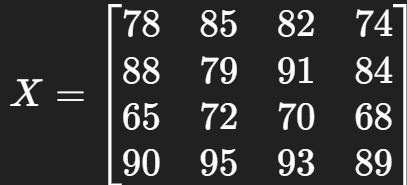

# PART A: Vector & Matrix Fundamentals
### 1️⃣ Represent student scores as vectors

Example: 

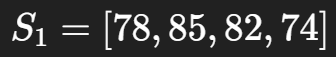




In [1]:
import numpy as np

s1 = np.array([78, 85, 82, 74])
s2 = np.array([88, 79, 91, 84])

### 2️⃣ Compute Norms
Norm-1 (Manhattan norm)

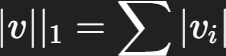

Example:

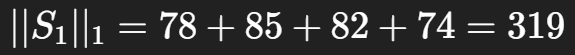


In [4]:
np.linalg.norm(s1 , 1)

np.float64(319.0)

### 3️⃣ Dot Product
Measures similarity between two students.

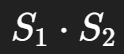

In [5]:
np.dot(s1, s2)

np.int64(27257)

### 4️⃣ Angle Between Vectors

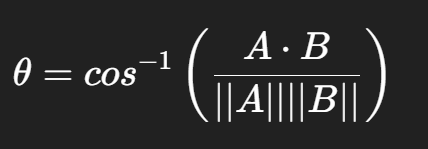

In [6]:
cos_theta = np.dot(s1, s2) / (np.linalg.norm(s1) * np.linalg.norm(s2))
angle = np.arccos(cos_theta)

### 5️⃣ Cross Product (3D)

Select 3 subjects.
Example:  

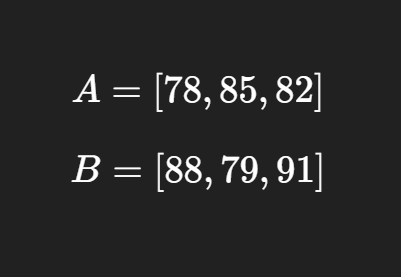

In [7]:
np.cross([78, 85, 82], [88, 79, 91])


array([ 1257,   118, -1318])

### 6️⃣ Vector Projection
Projection of vector A outo B

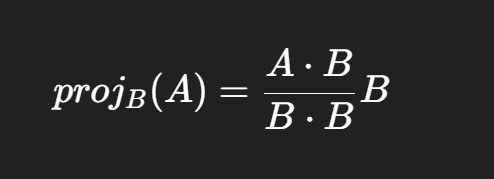

# PART B: Matrix Operations

### 4️⃣ Matrix representation

Matrix = Students × Subjects



In [8]:
X = np.array([
[78,85,82,74],
[88,79,91,84],
[65,72,70,68],
[90,95,93,89]
])

In [9]:
# Matrix Addition
X + X

array([[156, 170, 164, 148],
       [176, 158, 182, 168],
       [130, 144, 140, 136],
       [180, 190, 186, 178]])

In [10]:
#matrix multiplication
X @ X
np.matmul(X, X.T)

array([[25509, 27257, 21962, 29307],
       [27257, 29322, 23490, 31364],
       [21962, 23490, 18933, 25252],
       [29307, 31364, 25252, 33695]])

In [11]:
# transpose
X.T

array([[78, 88, 65, 90],
       [85, 79, 72, 95],
       [82, 91, 70, 93],
       [74, 84, 68, 89]])

In [12]:
#Determinant
np.linalg.det(X)

np.float64(-18498.99999999994)

In [13]:
#inverse
np.linalg.inv(X)

array([[-0.06324666, -0.01740635, -0.33304503,  0.32347694],
       [ 0.04286718, -0.06854425, -0.01956863,  0.04400238],
       [ 0.20168658,  0.09995135,  0.25093248, -0.45375426],
       [-0.19255095, -0.01367641,  0.09546462,  0.11130331]])

# PART C: Linear Transformations & Geometry

Line 
A line in vector space in 

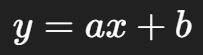

Example: relation Math and physics scores.

---

**Plane**
in 3D space:
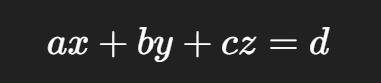

Example:
Math + Phsics + Chemistry scores.

##### Hyperplane
In higher dimensions:
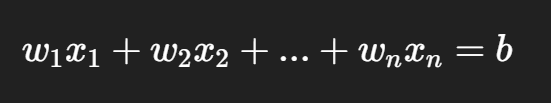

Used in Machine Learing classifiers(SVM).

**Dimensionality**

| Dimension | Example                    |
| --------- | -------------------------- |
| 1D        | single score               |
| 2D        | Math vs Physics            |
| 3D        | Math + Physics + Chemistry |
| ND        | many subjects              |


# PART D: Eigenvalues & Decomposition

### 7️⃣ Eigevalues & Eigenvectors
Used to understand **variance in data**.

steps:
1️⃣ compute covariance matrix


In [14]:
cov = np.cov(X.T)
cov

array([[130.91666667,  83.08333333, 120.        , 105.08333333],
       [ 83.08333333,  94.91666667,  76.66666667,  70.25      ],
       [120.        ,  76.66666667, 110.        ,  96.33333333],
       [105.08333333,  70.25      ,  96.33333333,  90.25      ]])

In [15]:
#2️⃣ Eigenvalues

eig_values, eig_vectors = np.linalg.eig(cov)
print("Eigenvalues:", eig_values)

#Eigenvalues show importance of each feature direction.

Eigenvalues: [3.87382478e+02 3.44491797e+01 1.80796898e-14 4.25167565e+00]


# 8️⃣ LU Decomposition
matrix factorization:

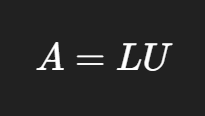

where

L= lower trianguler
U= upper trianguler



In [16]:
from scipy.linalg import lu
P, L, U = lu(X)
print("P:\n", P)

P:
 [[0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]


### 9️⃣ Singuler value decomposition(svd)

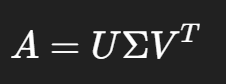


In [18]:
U,S,V = np.linalg.svd(X)
print("U:\n", U)

U:
 [[-0.48726279  0.41008135  0.71063729 -0.29900317]
 [-0.52195616 -0.84008481  0.07281596 -0.12851892]
 [-0.41982349  0.28394024 -0.6765124  -0.53428189]
 [-0.56025439  0.21323398 -0.17895094  0.78014284]]


uses:

- dimensionality reduction
- recommendation systems
- noise reduction


# PAET E: Dimensionality reduction

### 1️⃣0️⃣ Principal component analysis(PCA)
reduce dataset to 2 dimensions.
 

In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
print("Reduced Data:\n", X_reduced)

Reduced Data:
 [[ -3.65101567   3.98747669]
 [  9.05249395  -8.27834545]
 [-25.63850154  -0.05806149]
 [ 20.23702326   4.34893025]]


Benefits:

- reduce features
- visualize data
- remove correlation

### 1️⃣1️⃣ Linear Discriminant analysis(LDA)

Used for classification

Example:
Classify students:

- Above Average
- Below Average

In [24]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Student score matrix
X = np.array([
    [78,85,82,74],
    [88,79,91,84],
    [65,72,70,68],
    [90,95,93,89]
])

y = np.array([0,0,1,1])

lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X, y)

print("LDA Reduced Data:\n", X_lda)

LDA Reduced Data:
 [[ 0.70069045]
 [-1.2910864 ]
 [ 0.38578629]
 [ 0.20460967]]


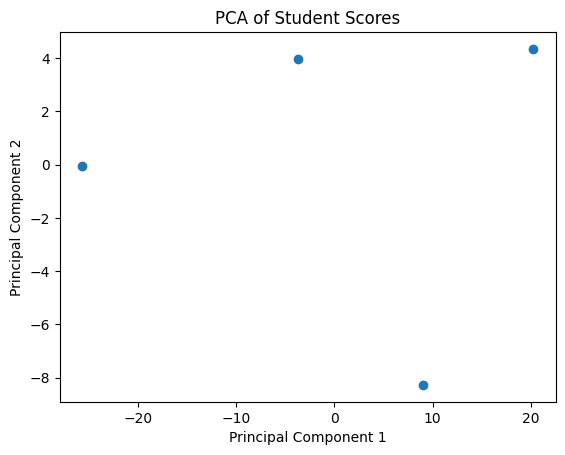

In [22]:
import matplotlib.pyplot as plt

plt.scatter(X_reduced[:,0], X_reduced[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Student Scores")
plt.show()

# 🧾 Final Conclusion (Write This)

- Linear Algebra plays a crucial role in data science and machine learning.
In this project we represented student scores using vectors and matrices, computed norms, dot products, projections, and performed matrix operations.

- Eigenvalues and eigenvectors helped understand the variance structure of the dataset.
Matrix decompositions such as LU and SVD simplified computations.

- Finally, PCA reduced dimensionality, while LDA classified students into performance categories.

- Thus, this project demonstrates how linear algebra concepts are applied in real-world data analysis.

# 📊 1️⃣ Subject Score Comparison Graph
Shows student performance across subjects.


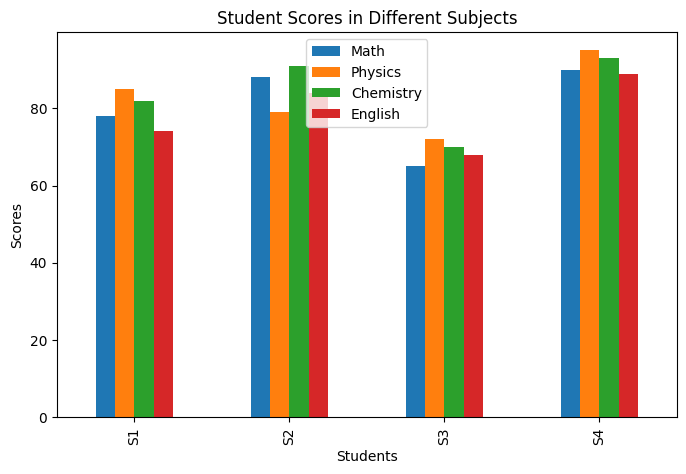

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

students = ["S1","S2","S3","S4"]

df = pd.DataFrame(X, columns=["Math","Physics","Chemistry","English"], index=students)

df.plot(kind="bar", figsize=(8,5))

plt.title("Student Scores in Different Subjects")
plt.xlabel("Students")
plt.ylabel("Scores")
plt.legend()
plt.show()

# 📊 2️⃣ Vector Visualization (Math vs Physics)

Shows vectors of students in 2D space.

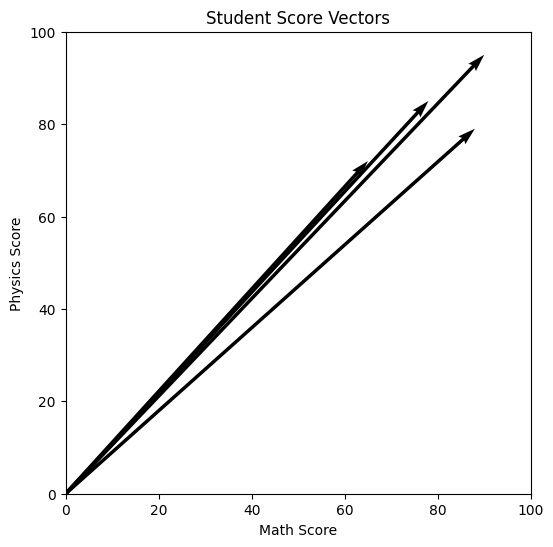

In [26]:
math = X[:,0]
physics = X[:,1]

plt.figure(figsize=(6,6))

for i in range(len(math)):
    plt.quiver(0,0,math[i],physics[i], angles='xy', scale_units='xy', scale=1)

plt.xlim(0,100)
plt.ylim(0,100)

plt.xlabel("Math Score")
plt.ylabel("Physics Score")
plt.title("Student Score Vectors")

plt.show()

# 📊 3️⃣ Eigenvalue Importance Graph

Shows which direction has more variance.

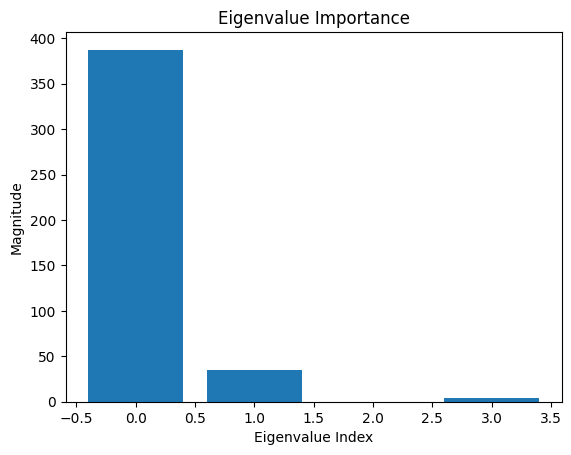

In [27]:
plt.bar(range(len(eig_values)), eig_values)

plt.xlabel("Eigenvalue Index")
plt.ylabel("Magnitude")
plt.title("Eigenvalue Importance")

plt.show()

# 📊 4️⃣ PCA Visualization (2D)

You already added PCA but add color labels.

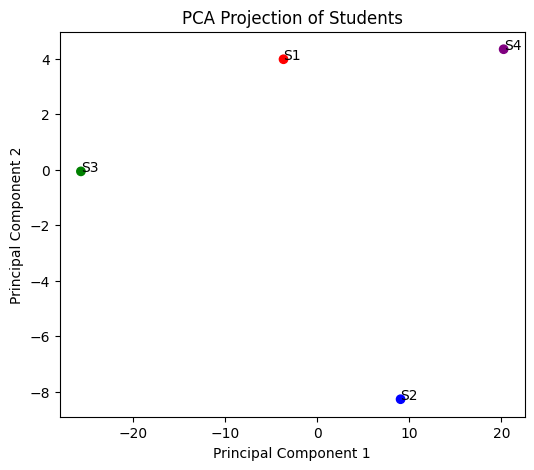

In [28]:
plt.figure(figsize=(6,5))

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=['red','blue','green','purple'])

for i, student in enumerate(["S1","S2","S3","S4"]):
    plt.text(X_reduced[i,0], X_reduced[i,1], student)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Students")

plt.show()

# 📊 5️⃣ LDA Classification Graph

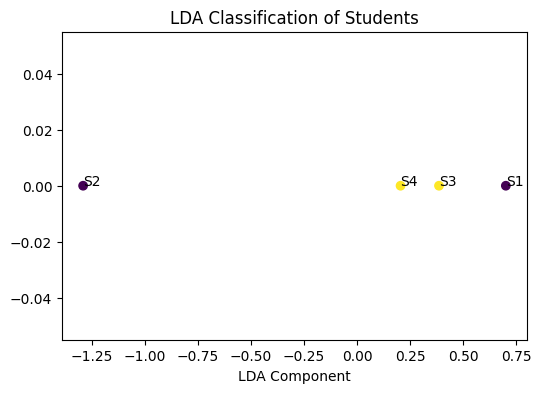

In [29]:
plt.figure(figsize=(6,4))

plt.scatter(X_lda, [0]*len(X_lda), c=y)

for i, student in enumerate(["S1","S2","S3","S4"]):
    plt.text(X_lda[i],0, student)

plt.title("LDA Classification of Students")
plt.xlabel("LDA Component")

plt.show()